#Detecting Pneumonia in X-Ray Images#

The reason why we find this problem particularly useful is more than 1 million adults are hospitalized with pneumonia and around 50,000 die from the disease every year in the US alone. Chest X-rays are currently the best available method for diagnosing pneumonia , playing a crucial role in clinical care and epidemiological studies . However, detecting pneumonia in chest X-rays is a challenging task that relies on the availability of expert radiologists(as reported by WHO).


In [1]:
import os
from glob import glob
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
import gzip
%matplotlib inline
import keras
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout,Reshape,Conv2D,MaxPooling2D,UpSampling2D,Conv2DTranspose,BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adadelta, RMSprop,SGD,Adam
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
from keras.utils import to_categorical
import seaborn
import cv2
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
#from keras.applications.mobilenet import MobileNet
#from sklearn.metrics import roc_auc_score
#from sklearn.metrics import roc_curve
#from sklearn.metrics import auc
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")
import cv2
from skimage.transform import resize
keras.backend.backend()

from tensorflow.image import resize as reZ
from tensorflow import reshape as tfreshape

Using TensorFlow backend.


#Load the data#

In [2]:
image_size = 256


In [3]:
X_train = reZ(np.load('X_train-pneunonia-grayscale-(5216, 768, 768, 3).npz')['arr_0'],(image_size,image_size))
y_train = np.load('Y_train-pneunonia-grayscale-(5216, 768, 768, 3).npz')['arr_0']
X_test = reZ(np.load('X_test-pneunonia-grayscale-(624, 768, 768, 3).npz')['arr_0'],(image_size,image_size))
y_test = np.load('Y_test-pneunonia-grayscale-(624, 768, 768, 3).npz')['arr_0']
    #'X_val-pneunonia-grayscale-(16, 768, 768, 3).npz'
#'Y_val-pneunonia-grayscale-(16, 768, 768, 3).npz'
# Encode labels to hot vectors (ex : 2 -> [0,0,1,0,0,0,0,0,0,0])





In [4]:
from keras.utils.np_utils import to_categorical
y_trainHot = to_categorical(y_train, num_classes = 2)
y_testHot = to_categorical(y_test, num_classes = 2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(5216, 256, 256, 3)
(5216,)
(624, 256, 256, 3)
(624,)


#show some images between normal vs pneumonia#

{0: 'No Pneumonia', 1: 'Yes Pneumonia'}


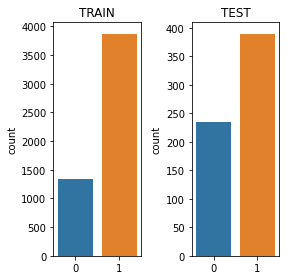

In [5]:
map_characters = {0: 'No Pneumonia', 1: 'Yes Pneumonia'}
dict_characters=map_characters
plt.subplot(1,3,1)
seaborn.countplot(np.argmax(y_trainHot, axis=1)).set_title('TRAIN')

plt.subplot(1,3,2)
seaborn.countplot(np.argmax(y_testHot, axis=1)).set_title('TEST')


plt.tight_layout()
print(dict_characters)

**Explain the need of imbalanced ...**

In [6]:
# Deal with imbalanced class sizes below
# Make Data 1D for compatability upsampling methods
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
X_trainShape = X_train.shape[1]*X_train.shape[2]*X_train.shape[3]
X_testShape = X_test.shape[1]*X_test.shape[2]*X_test.shape[3]
print(X_trainShape)
print(X_testShape)
X_trainFlat = X_train.numpy().reshape(X_train.shape[0], X_trainShape)
X_testFlat = X_test.numpy().reshape(X_test.shape[0], X_testShape)
Y_train = y_train
Y_test = y_test
print(X_trainFlat.shape)
print(X_testFlat.shape)

196608
196608
(5216, 196608)
(624, 196608)


In [17]:
#ros = RandomOverSampler(sampling_strategy='auto')
ros = RandomUnderSampler(sampling_strategy='auto')
X_trainRos, Y_trainRos = ros.fit_sample(X_trainFlat, Y_train)
X_testRos, Y_testRos = ros.fit_sample(X_testFlat, Y_test)
# Encode labels to hot vectors (ex : 2 -> [0,0,1,0,0,0,0,0,0,0])
Y_trainRosHot = to_categorical(Y_trainRos, num_classes = 2)
Y_testRosHot = to_categorical(Y_testRos, num_classes = 2)
# Make Data 2D again
for i in range(len(X_trainRos)):
    height, width, channels = image_size,image_size,3
    X_trainRosReshaped = X_trainRos.reshape(len(X_trainRos),height,width,channels)
for i in range(len(X_testRos)):
    height, width, channels = image_size,image_size,3
    X_testRosReshaped = X_testRos.reshape(len(X_testRos),height,width,channels)


{0: 'No Pneumonia', 1: 'Yes Pneumonia'}


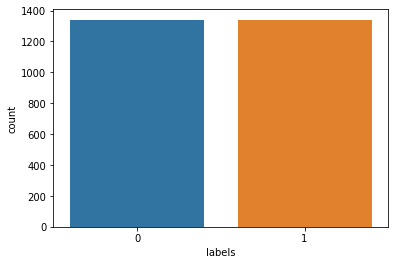

In [18]:
# Plot Label Distribution
dfRos = pd.DataFrame()
dfRos["labels"]=Y_trainRos
labRos = dfRos['labels']
df = pd.DataFrame()
df["labels"]=y_train
lab = df['labels']
dist = lab.value_counts()
distRos = lab.value_counts()
# Plot Label Distribution
import seaborn
seaborn.countplot(labRos)
print(dict_characters)

**We will try to do Transfer learning w/ VGG16 Convolutional Network and Transfer learning w/ InceptionV3 Convolutional Network**



In [19]:
# Helper Functions  Learning Curves and Confusion Matrix
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import itertools
class MetricsCheckpoint(Callback):
    """Callback that saves metrics after each epoch"""
    def __init__(self, savepath):
        super(MetricsCheckpoint, self).__init__()
        self.savepath = savepath
        self.history = {}
    def on_epoch_end(self, epoch, logs=None):
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)
        np.save(self.savepath, self.history)

def plotKerasLearningCurve():
    plt.figure(figsize=(10,5))
    metrics = np.load('logs.npy',allow_pickle=True)[()]
    filt = ['acc'] # try to add 'loss' to see the loss learning curve
    for k in filter(lambda x : np.any([kk in x for kk in filt]), metrics.keys()):
        l = np.array(metrics[k])
        plt.plot(l, c= 'r' if 'val' not in k else 'b', label='val' if 'val' in k else 'train')
        x = np.argmin(l) if 'loss' in k else np.argmax(l)
        y = l[x]
        plt.scatter(x,y, lw=0, alpha=0.25, s=100, c='r' if 'val' not in k else 'b')
        plt.text(x, y, '{} = {:.4f}'.format(x,y), size='15', color= 'r' if 'val' not in k else 'b')   
    plt.legend(loc=4)
    plt.axis([0, None, None, None]);
    plt.grid()
    plt.xlabel('Number of epochs')
    plt.ylabel('Accuracy')

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (5,5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def plot_learning_curve(history):
    plt.figure(figsize=(8,8))
    plt.subplot(1,2,1)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('./accuracy_curve.png')
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('./loss_curve.png')

#Building the model#
**Explain about vgg16 and inception v3, and since we do not have enough data to train on CNN, so we have to use pretrained model.....**

In [20]:
import sklearn
from sklearn.utils import class_weight
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adadelta, RMSprop,SGD,Adam,Adagrad
from sklearn.metrics import confusion_matrix

map_characters1 = {0: 'No Pneumonia', 1: 'Yes Pneumonia'}

class_weight1 = class_weight.compute_class_weight('balanced', np.unique(y_train), y_train)

weight_path1 = 'keras-pretrained-models/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'

weight_path2 = 'keras-pretrained-models/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'

pretrained_model_1 = VGG16(weights = weight_path1, include_top=False, input_shape=(image_size, image_size, 3))

pretrained_model_2 = InceptionV3(weights = weight_path2, include_top=False, input_shape=(image_size, image_size, 3))


#keras.optimizers.Adagrad(learning_rate=0.01)
def training_report(model,history,xtest,ytest,labels):
    # Evaluate model
    score = model.evaluate(xtest,ytest, verbose=0)
    print('\nKeras CNN - accuracy:', score[1], '\n')
    pprint(score)
    y_pred = model.predict(xtest)
    print('\n', sklearn.metrics.classification_report(np.where(ytest > 0)[1], np.argmax(y_pred, axis=1), target_names=list(labels.values())), sep='') 
    Y_pred_classes = np.argmax(y_pred,axis = 1) 
    Y_true = np.argmax(ytest,axis = 1) 
    confusion_mtx = (Y_true, Y_pred_classes)
    plotKerasLearningCurve()
    plt.show()
    plot_learning_curve(history)
    plt.show()
    plot_confusion_matrix(confusion_mtx, classes = list(labels.values()))
    plt.show()

def pretrainedNetwork(xtrain,ytrain,xtest,ytest,pretrainedmodel,pretrainedweights,classweight,numclasses,numepochs,optimizer):
    base_model = pretrained_model_1 # Topless
    # Add top layer
    x = base_model.output
    x = Flatten()(x)
    predictions = Dense(numclasses, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    # Train top layer
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(loss='binary_crossentropy', 
                  optimizer=optimizer, 
                  metrics=['acc'])
    filepath="weights-improvement-{epoch:02d}-{loss:.4f}-pretrainedNetwork.hdf5"
    weights_improvement = ModelCheckpoint(filepath, monitor='val_acc', verbose=1, save_best_only=True, mode='max')
    callbacks_list = [keras.callbacks.EarlyStopping(monitor='val_acc', patience=3, verbose=1),weights_improvement]
    model.summary()
    # Fit model
    history = model.fit(xtrain,ytrain, epochs=numepochs, validation_data=(xtest,ytest), verbose=1,callbacks = [MetricsCheckpoint('logs')])
    return model,history

In [21]:
class_weight1 = class_weight.compute_class_weight('balanced', np.unique(y_train), y_train)
print("Old Class Weights: ",class_weight1)
class_weight2 = class_weight.compute_class_weight('balanced', np.unique(Y_trainRos), Y_trainRos)
print("New Class Weights: ",class_weight2)

Old Class Weights:  [1.9448173  0.67303226]
New Class Weights:  [1. 1.]


** Running VGG16 Convolutional Network**

In [23]:
optimizer1 = RMSprop(lr=0.0005)
model, history = pretrainedNetwork(X_train, y_trainHot, X_test, y_testHot,pretrained_model_1,weight_path1,class_weight2,2,8,optimizer1)


Model: "model_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 256, 256, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 256, 256, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 256, 256, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 128, 128, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 128, 128, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 128, 128, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 64, 64, 128)       0   


Keras CNN - accuracy: 0.8108974099159241 

[6.532071113586426, 0.8108974099159241]

               precision    recall  f1-score   support

 No Pneumonia       0.98      0.50      0.67       234
Yes Pneumonia       0.77      0.99      0.87       390

     accuracy                           0.81       624
    macro avg       0.88      0.75      0.77       624
 weighted avg       0.85      0.81      0.79       624



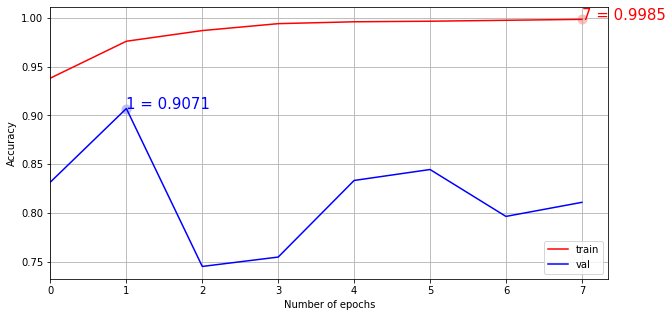

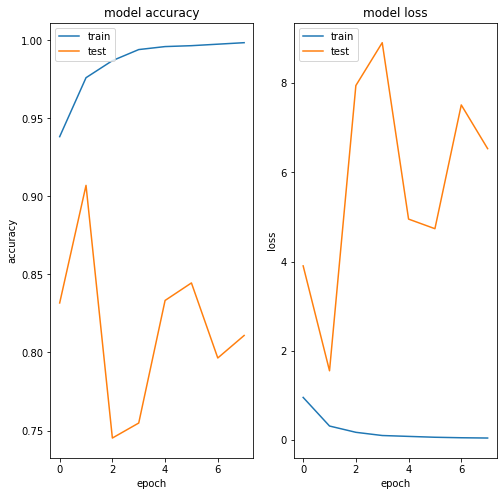

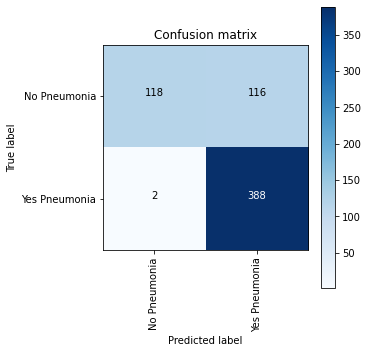

In [14]:
from pprint import pprint
training_report(model, history, X_test, y_testHot,map_characters1)

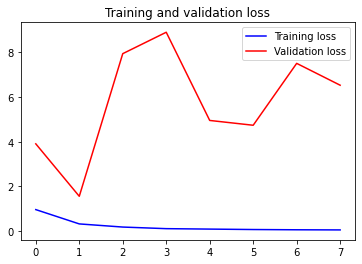

In [15]:

loss = history.history['loss']
val_loss = history.history['val_loss']
epochZ = range(8)
plt.figure()
plt.plot(epochZ, loss, 'b', label='Training loss')
plt.plot(epochZ, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

**Running Transfer learning w/ InceptionV3 Convolutional Network model**

In [24]:
optimizer1 = Adadelta()
class_weight2 = class_weight.compute_class_weight('balanced', np.unique(Y_trainRos), Y_trainRos)
print("New Class Weights: ",class_weight2)
model2, history2 = pretrainedNetwork(X_train, y_trainHot, X_test, y_testHot,pretrained_model_2,weight_path2,class_weight2,2,64,optimizer1)

New Class Weights:  [1. 1.]
Model: "model_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 256, 256, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 256, 256, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 256, 256, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 128, 128, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 128, 128, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 128, 128, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (N

163/163 [==============================] - 131s 801ms/step - loss: 0.3830 - acc: 0.9383 - val_loss: 1.7563 - val_acc: 0.7756
Epoch 25/64
163/163 [==============================] - 130s 799ms/step - loss: 0.3713 - acc: 0.9394 - val_loss: 1.7807 - val_acc: 0.7756
Epoch 26/64
163/163 [==============================] - 130s 800ms/step - loss: 0.3604 - acc: 0.9421 - val_loss: 1.8013 - val_acc: 0.7772
Epoch 27/64
163/163 [==============================] - 130s 799ms/step - loss: 0.3508 - acc: 0.9417 - val_loss: 1.7907 - val_acc: 0.7756
Epoch 28/64
163/163 [==============================] - 130s 800ms/step - loss: 0.3415 - acc: 0.9440 - val_loss: 1.7708 - val_acc: 0.7756
Epoch 29/64
163/163 [==============================] - 130s 799ms/step - loss: 0.3326 - acc: 0.9446 - val_loss: 1.7266 - val_acc: 0.7756
Epoch 30/64
163/163 [==============================] - 130s 799ms/step - loss: 0.3251 - acc: 0.9463 - val_loss: 1.7624 - val_acc: 0.7740
Epoch 31/64
163/163 [==============================] 


Keras CNN - accuracy: 0.7836538553237915 

[1.7905209064483643, 0.7836538553237915]

               precision    recall  f1-score   support

 No Pneumonia       0.98      0.43      0.60       234
Yes Pneumonia       0.74      0.99      0.85       390

     accuracy                           0.78       624
    macro avg       0.86      0.71      0.73       624
 weighted avg       0.83      0.78      0.76       624



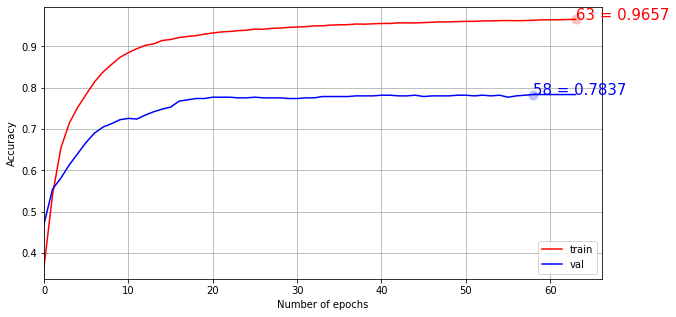

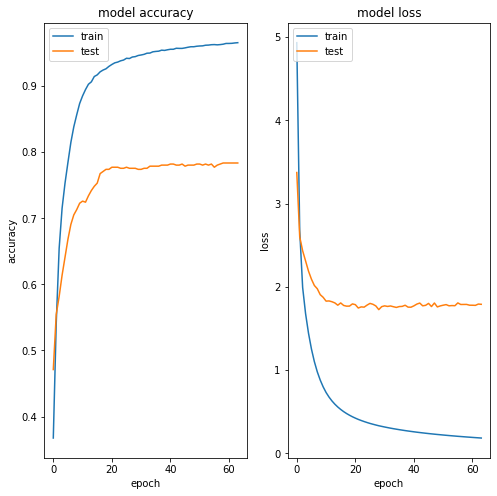

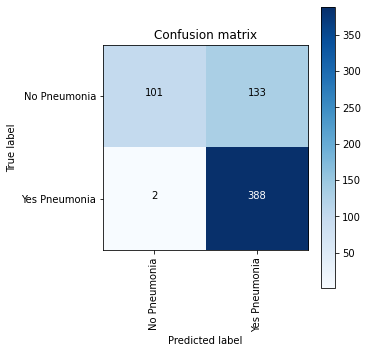

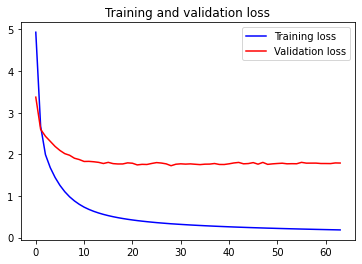

In [25]:
training_report(model2, history2,  X_test, y_testHot,map_characters1)
loss = history2.history['loss']
val_loss = history2.history['val_loss']
epochs = range(64)
plt.figure()
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# Training on GPU

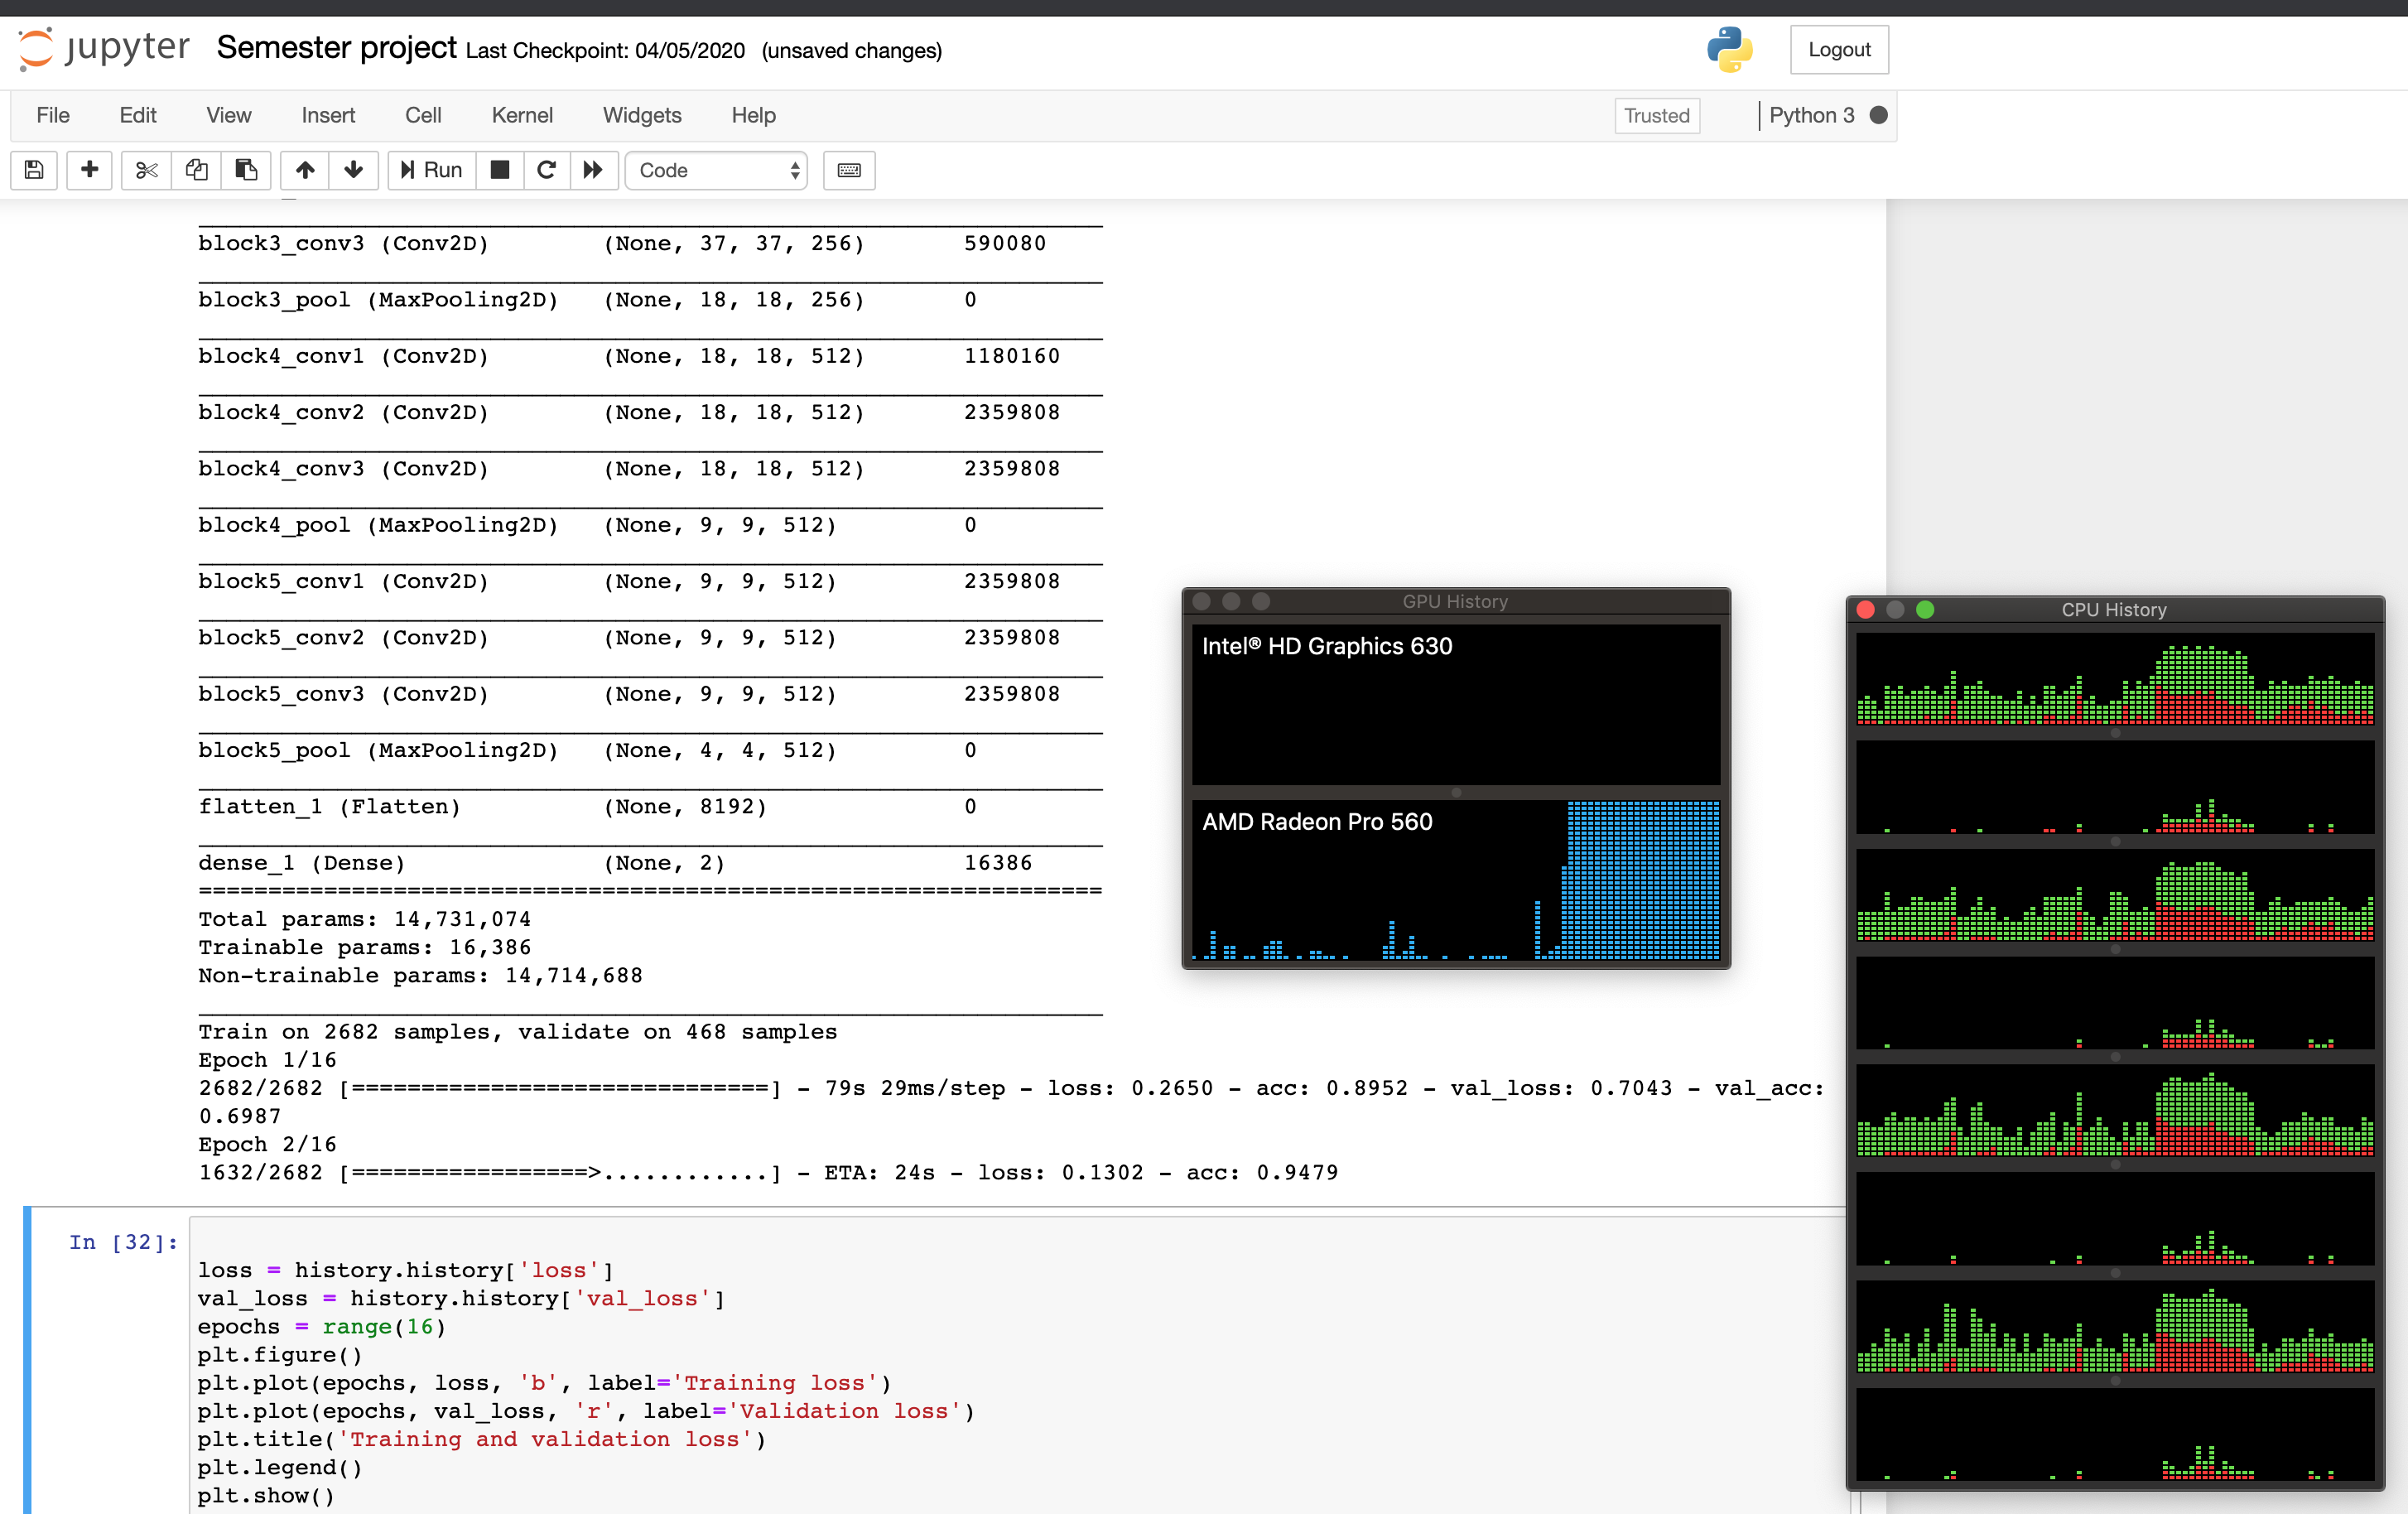

#Conclusion#

The result of VGG16 Convolutional Network gives ...

The result of  InceptionV3 Convolutional Network gives.....

